<a href="https://colab.research.google.com/github/Al3x4ndra/Perceptron-ML/blob/main/Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pesos aprendidos: [-7.876  0.26 ]
Viés aprendido: -1.1400000000000006


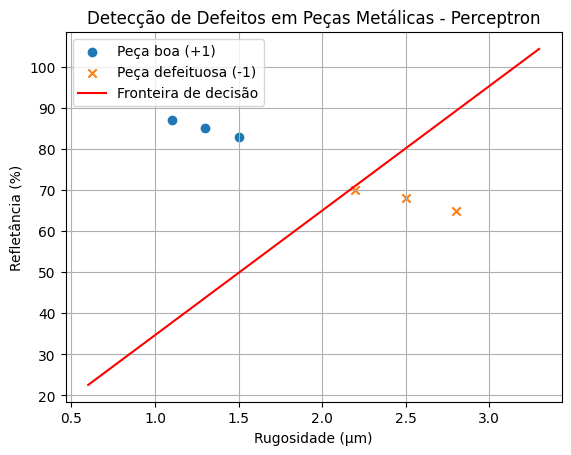

Peça 1: BOA
Peça 2: DEFEITUOSA


In [1]:
# --------------------------------------------------------
# PERCEPTRON PARA DETECÇÃO DE DEFEITOS EM PEÇAS METÁLICAS
# Rugosidade (µm) e Refletância (%) como atributos
# --------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Criando o conjunto de dados
# -------------------------------

# Dados simulados
# Formato: [rugosidade, refletancia]
X = np.array([
    [1.1, 87],
    [1.3, 85],
    [1.5, 83],
    [2.2, 70],
    [2.5, 68],
    [2.8, 65],
])

# Etiquetas: +1 = peça boa ; -1 = peça defeituosa
y = np.array([+1, +1, +1, -1, -1, -1])

# -------------------------------
# 2. Perceptron
# -------------------------------

class Perceptron:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.activation = self._step

    def _step(self, x):
        return np.where(x >= 0, 1, -1)

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Inicializa pesos e viés
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.w) + self.b
                y_predicted = self.activation(linear_output)

                # Regra de atualização do Perceptron
                update = self.lr * (y[idx] - y_predicted)
                self.w += update * x_i
                self.b += update

    def predict(self, X):
        linear_output = np.dot(X, self.w) + self.b
        return self.activation(linear_output)

# -------------------------------
# 3. Treinando o modelo
# -------------------------------

model = Perceptron(learning_rate=0.01, n_iters=1000)
model.fit(X, y)

print("Pesos aprendidos:", model.w)
print("Viés aprendido:", model.b)

# -------------------------------
# 4. Visualização da fronteira de decisão
# -------------------------------

def plot_decision_boundary(X, y, model):
    fig, ax = plt.subplots()

    # Separa pontos por classe
    good = y == 1
    bad = y == -1

    ax.scatter(X[good, 0], X[good, 1], marker="o", label="Peça boa (+1)")
    ax.scatter(X[bad, 0], X[bad, 1], marker="x", label="Peça defeituosa (-1)")

    # Criar reta de decisão
    x1_min, x1_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    x1 = np.linspace(x1_min, x1_max, 100)
    # w1*x1 + w2*x2 + b = 0  →  x2 = -(w1*x1 + b)/w2
    x2 = -(model.w[0] * x1 + model.b) / model.w[1]

    ax.plot(x1, x2, label="Fronteira de decisão", color="red")

    ax.set_xlabel("Rugosidade (µm)")
    ax.set_ylabel("Refletância (%)")
    ax.legend()
    plt.title("Detecção de Defeitos em Peças Metálicas - Perceptron")
    plt.grid(True)
    plt.show()

plot_decision_boundary(X, y, model)

# -------------------------------
# 5. Testando novas peças
# -------------------------------

novas_pecas = np.array([
    [1.2, 86],  # Deve ser boa
    [2.6, 67],  # Deve ser defeituosa
])

pred = model.predict(novas_pecas)

for i, p in enumerate(pred):
    if p == 1:
        print(f"Peça {i+1}: BOA")
    else:
        print(f"Peça {i+1}: DEFEITUOSA")
